In [ ]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# ==========================================
# 2. LOAD DATASET
# ==========================================

df = pd.read_csv("Mall_Customers.csv")


In [ ]:
# ==========================================
# 3. UNDERSTAND DATA
# ==========================================




df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
# ==========================================
# 4. SELECT FEATURES
# ==========================================

X = df[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]



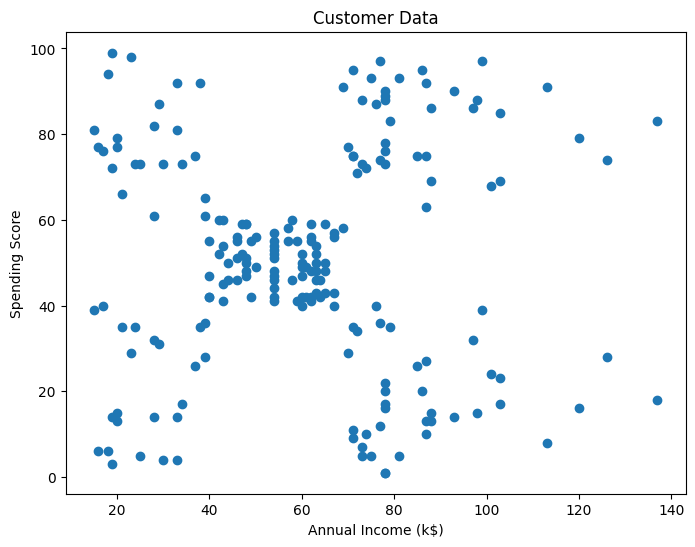

In [ ]:
# ==========================================
# 5. VISUALIZE DATA
# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Customer Data")

plt.show()

In [ ]:
# ==========================================
# 6. FEATURE SCALING
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


In [ ]:
# ==========================================
# 7. CREATE K-MEANS MODEL
# ==========================================

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

In [ ]:
# ==========================================
# 8. TRAIN MODEL
# ==========================================

kmeans.fit(X_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [ ]:
# ==========================================
# 9. GET CLUSTERS
# ==========================================

clusters = kmeans.labels_

print(clusters)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


In [ ]:
# ==========================================
# 10. ADD CLUSTER TO DATAFRAME
# ==========================================

df["Cluster"] = clusters

df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


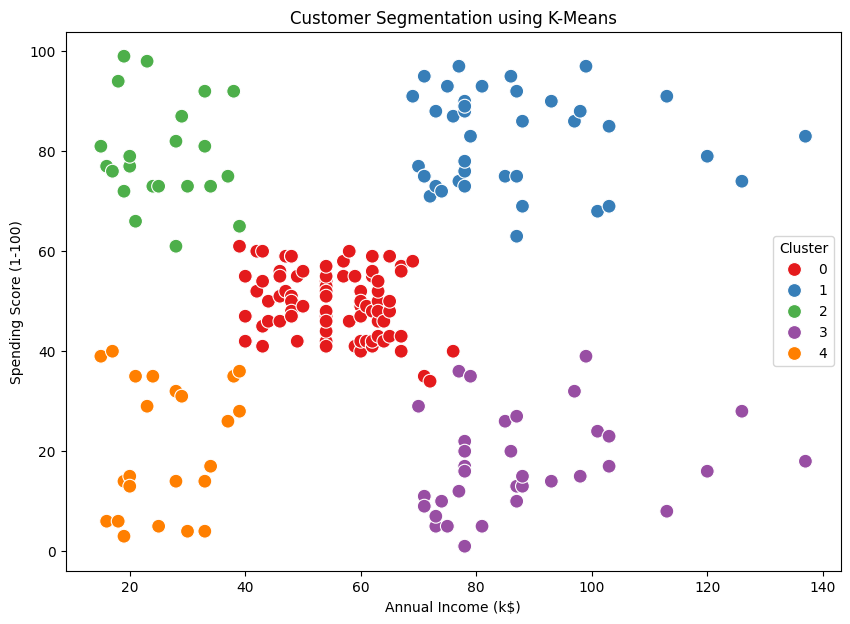

In [ ]:
# ==========================================
# 11. VISUALIZE CLUSTERS
# ==========================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("Customer Segmentation using K-Means")
plt.show()

In [ ]:
# ==========================================
# 12. CLUSTER CENTERS
# ==========================================

centers = kmeans.cluster_centers_

print("Cluster Centers:")
print(centers)

Cluster Centers:
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


In [ ]:
# Convert cluster centers back to original scale

centers_original = scaler.inverse_transform(centers)

print(centers_original)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [ ]:
# ==========================================
# 13. CLUSTER CENTER TABLE
# ==========================================

centers_df = pd.DataFrame(
    centers_original,
    columns=[
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
)

print(centers_df)

   Annual Income (k$)  Spending Score (1-100)
0           55.296296               49.518519
1           86.538462               82.128205
2           25.727273               79.363636
3           88.200000               17.114286
4           26.304348               20.913043
